# Exploración de `ratings`

## 1. Introducción

Este notebook explora la tabla de calificaciones (`ratings.csv`) de forma aislada, sin combinarla
todavía con `movies` ni `tags` (eso se hace en `movies_ratings.ipynb` y
`movies_tags_ratings.ipynb`). El objetivo es caracterizar las calificaciones en sí mismas:

* ¿Cuántas calificaciones hay, de cuántos usuarios y sobre cuántas películas?
* ¿Cómo se distribuye la calificación (`rating`) en sí misma? ¿Hay sesgos hacia ciertos valores?
* ¿Cómo ha evolucionado la actividad de calificación en el tiempo?
* ¿Todos los usuarios califican con una frecuencia parecida, o hay usuarios muy activos que dominan
  el dataset?

**Aviso sobre el origen de los datos:** `ratings.csv` es la **tabla completa y real**, sin muestreo —
todas las cifras de este notebook corresponden al dataset completo (31,963,989 calificaciones), no a
una estimación.

## 2. Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## 3. Carga de datos

In [1]:
RUTA_RATINGS = '../../../data/processed/ratings.csv'

ratings = pd.read_csv(RUTA_RATINGS)

print(f"ratings: {ratings.shape[0]:,} filas (tabla completa, sin muestreo)")

ratings: 31,963,989 filas (tabla completa, sin muestreo)


## 4. Exploración inicial de `ratings`

**Qué se calcula:** dimensiones, tipos de dato por columna, nulos, filas totalmente duplicadas y
duplicados de `(userId, movieId)`.

**Por qué es necesario:** antes de calcular cualquier estadística hay que confirmar el tamaño real de
la tabla y que no haya calificaciones duplicadas (una misma persona calificando la misma película dos
veces), lo cual invalidaría cualquier promedio o conteo posterior.

In [2]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31963989 entries, 0 to 31963988
Data columns (total 4 columns):
 #   Column           Dtype  
---  ------           -----  
 0   userId           int64  
 1   movieId          int64  
 2   rating           float64
 3   rating_datetime  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 975.6+ MB


In [3]:
print(ratings.head(10))

   userId  movieId  rating      rating_datetime
0       1       17     4.0  1999-12-03 19:24:37
1       1       25     1.0  1999-12-03 19:43:48
2       1       29     2.0  1999-11-22 00:36:16
3       1       30     5.0  1999-12-03 19:24:37
4       1       32     5.0  1999-11-22 00:00:58
5       1       34     2.0  1999-11-21 23:54:51
6       1       36     1.0  1999-12-03 19:23:28
7       1       80     5.0  1999-12-03 19:22:23
8       1      110     3.0  1999-11-22 00:38:39
9       1      111     5.0  1999-12-03 19:23:28


In [4]:
print("Valores nulos por columna:")
print(ratings.isnull().sum())
print()
print("Filas totalmente duplicadas:", ratings.duplicated().sum())
print("Duplicados de (userId, movieId):", ratings.duplicated(subset=['userId', 'movieId']).sum())
print()
print("Usuarios únicos:", ratings['userId'].nunique())
print("Películas calificadas (movieId únicos):", ratings['movieId'].nunique())
print()
print("Valores únicos de rating:", sorted(ratings['rating'].unique()))

Valores nulos por columna:
userId             0
movieId            0
rating             0
rating_datetime    0
dtype: int64

Filas totalmente duplicadas: 0
Duplicados de (userId, movieId): 0

Usuarios únicos: 200948
Películas calificadas (movieId únicos): 83852

Valores únicos de rating: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


**Resultados:** la tabla tiene 31,963,989 filas (`userId`, `movieId`, `rating`,
`rating_datetime`), sin valores nulos y sin duplicados (ni exactos ni de `(userId, movieId)`) — cada
combinación usuario-película aparece una única vez. Hay 200,948 usuarios únicos y 83,852 películas
calificadas (de las 86,967 del catálogo completo). `rating` toma 10 valores posibles, de 0.5 a 5.0 en
pasos de 0.5 (no solo estrellas enteras).

**Conclusión:** los datos están limpios y no requieren depuración adicional antes del análisis. La
diferencia entre películas del catálogo (86,967) y películas calificadas (83,852) es una limitación a
tener presente: 3,115 películas nunca fueron calificadas por nadie en este dataset.

### Unidad de observación

Cada fila de `ratings` representa **una calificación**: un usuario calificando una película en un
momento determinado (`rating_datetime`). Como no hay duplicados de `(userId, movieId)`, cada usuario
aparece a lo más una vez por película — no hay "recalificaciones" registradas en este dataset.

## 5. Transformaciones

**Qué se hace:** se extrae el año (`anio`) desde `rating_datetime`.

**Por qué es necesaria:** es la única variable temporal disponible; convertirla a un entero simple
permite agrupar y graficar la actividad de calificación por año.

In [5]:
ratings['anio'] = pd.to_datetime(ratings['rating_datetime']).dt.year

ratings[['userId', 'movieId', 'rating', 'rating_datetime', 'anio']].head()

   userId  movieId  rating      rating_datetime  anio0       1       17     4.0  1999-12-03 19:24:37  19991       1       25     1.0  1999-12-03 19:43:48  19992       1       29     2.0  1999-11-22 00:36:16  19993       1       30     5.0  1999-12-03 19:24:37  19994       1       32     5.0  1999-11-22 00:00:58  1999

## 6. Exploración descriptiva de `ratings`

### 6.1 Cobertura general

**Qué se calcula:** número total de calificaciones, usuarios, películas calificadas y periodo
cubierto.

In [6]:
print(f"Total de calificaciones: {len(ratings):,}")
print(f"Usuarios que han calificado: {ratings['userId'].nunique():,}")
print(f"Películas calificadas: {ratings['movieId'].nunique():,} de 86,967 del catálogo")
print(f"Periodo cubierto: {ratings['anio'].min()} - {ratings['anio'].max()}")

Total de calificaciones: 31,963,989
Usuarios que han calificado: 200,948
Películas calificadas: 83,852 de 86,967 del catálogo
Periodo cubierto: 1995 - 2023


**Resultados:** 31,963,989 calificaciones, de 200,948 usuarios, sobre 83,852 películas (96.4%
del catálogo), cubriendo 29 años (1995-2023).

**Conclusión:** `ratings` es, por lejos, la tabla con mayor cobertura de usuarios y películas de las
tres del proyecto (frente a los 15,834 usuarios y 51,069 películas de `tags`), lo cual tiene sentido:
calificar es una acción más simple y rápida que escribir una etiqueta libre.

### 6.2 Estadísticas descriptivas y distribución de `rating`

**Qué se calcula:** media, mediana, moda, desviación estándar, cuartiles y frecuencia/proporción
de cada valor de `rating`.

**Por qué es relevante:** `rating` es la variable central de esta tabla: entender su forma (dónde se
concentran las calificaciones, qué tan dispersas están) es la base para cualquier análisis
posterior.

In [7]:
print(ratings['rating'].describe())
print()
print("Moda:", ratings['rating'].mode()[0])
print()
q1 = ratings['rating'].quantile(0.25)
q3 = ratings['rating'].quantile(0.75)
iqr = q3 - q1
print(f"Q1={q1}, Q3={q3}, IQR={iqr}")

count    3.196399e+07
mean     3.540369e+00
std      1.058978e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Moda: 4.0

Q1=3.0, Q3=4.0, IQR=1.0


In [8]:
frecuencia_rating = ratings['rating'].value_counts().sort_index()
proporcion_rating = (ratings['rating'].value_counts(normalize=True).sort_index() * 100).round(2)

pd.DataFrame({'frecuencia': frecuencia_rating, 'porcentaje (%)': proporcion_rating})

   frecuencia  porcentaje (%)rating                           0.5        524313            1.641.0        945797            2.961.5        530316            1.662.0       2026824            6.342.5       1682992            5.273.0       6049729           18.933.5       4283769           13.404.0       8359261           26.154.5       2969229            9.295.0       4591759           14.37

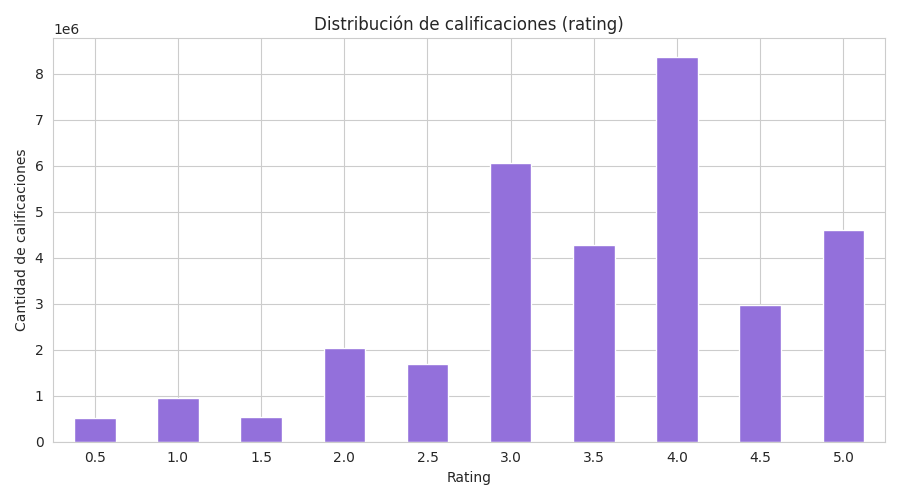

In [9]:
plt.figure(figsize=(9, 5))
frecuencia_rating.plot(kind='bar', color='mediumpurple')
plt.xlabel('Rating')
plt.ylabel('Cantidad de calificaciones')
plt.title('Distribución de calificaciones (rating)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Resultados:** media = 3.54, mediana = 3.5, moda = 4.0, desviación estándar ≈ 1.06. Q1 = 3.0,
Q3 = 4.0 (IQR = 1.0). La calificación más frecuente por amplio margen es 4.0 estrellas (26.15% de
todas las calificaciones, 8,359,261 registros), seguida de 3.0 (18.93%, 6,049,729) y 5.0 (14.37%,
4,591,759). Los valores bajos (0.5 a 1.5) son minoritarios, cada uno por debajo del 3%.

**Conclusión:** la distribución es asimétrica hacia la izquierda (cola en los ratings bajos): la moda
(4.0) supera a la media (3.54), lo que indica que aunque la mayoría de la gente califica alto, un
grupo más pequeño de calificaciones bajas jala el promedio hacia abajo. Además se observa un **sesgo
hacia calificaciones "redondas"**: los valores enteros (1.0, 2.0, 3.0, 4.0, 5.0) son consistentemente
más frecuentes que sus vecinos en .5 (ej. 3.0 con 18.93% frente a 3.5 con 13.40%; 4.0 con 26.15% frente
a 4.5 con 9.29%) — patrón típico que sugiere que los usuarios prefieren usar valores enteros aunque la
escala permita medios puntos.

No se aplica la regla de outliers por IQR aquí: `rating` es una variable **ordinal y acotada** entre
0.5 y 5.0, así que sus valores extremos (0.5 o 5.0) son simplemente el límite válido de la escala, no
observaciones anómalas.

### 6.3 Distribución temporal

**Qué se calcula:** cantidad de calificaciones por año.

**Por qué es relevante:** es la única variable temporal disponible; permite ver si la actividad de
calificación fue constante o tuvo picos/caídas a lo largo de los años que cubre el dataset.

In [10]:
por_anio = ratings['anio'].value_counts().sort_index()
print(por_anio.describe())
print()
print(por_anio.to_dict())

count    2.900000e+01
mean     1.102207e+06
std      4.892988e+05
min      4.000000e+00
25%      7.895190e+05
50%      1.117068e+06
75%      1.387205e+06
max      1.918222e+06
Name: count, dtype: float64

{1995: 4, 1996: 1571163, 1997: 685336, 1998: 301678, 1999: 1174621, 2000: 1912322, 2001: 1160096, 2002: 849758, 2003: 1011000, 2004: 1139068, 2005: 1752571, 2006: 1141704, 2007: 1023813, 2008: 1117068, 2009: 890695, 2010: 860070, 2011: 729297, 2012: 695489, 2013: 563301, 2014: 518523, 2015: 1743410, 2016: 1918222, 2017: 1824893, 2018: 1387205, 2019: 1379826, 2020: 1681334, 2021: 1234291, 2022: 907712, 2023: 789519}


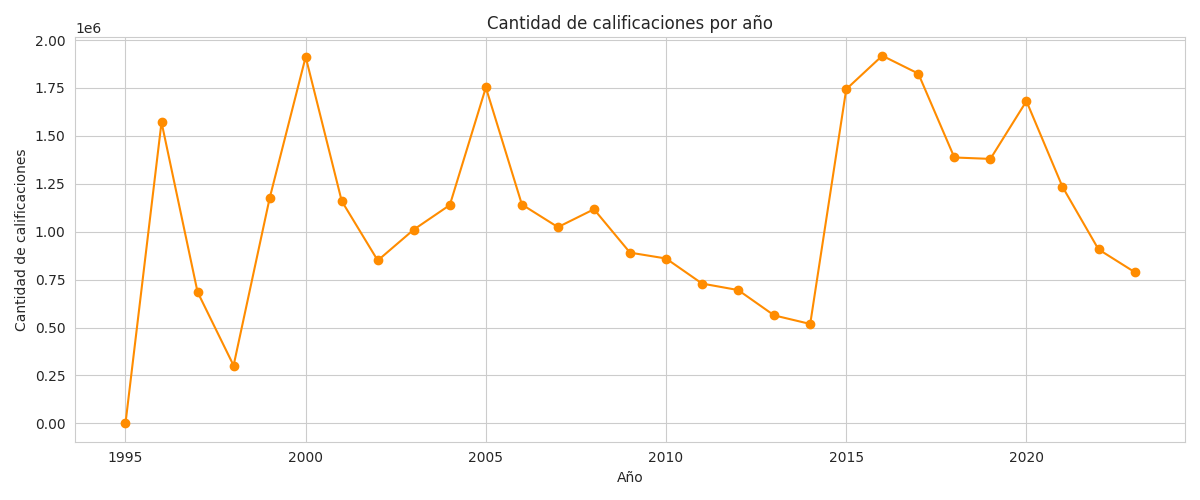

In [11]:
plt.figure(figsize=(12, 5))
por_anio.plot(kind='line', marker='o', color='darkorange')
plt.xlabel('Año')
plt.ylabel('Cantidad de calificaciones')
plt.title('Cantidad de calificaciones por año')
plt.tight_layout()
plt.show()

**Resultados:** el dataset cubre calificaciones desde 1995 hasta 2023 (29 años), aunque 1995
tiene solo 4 registros (prácticamente el arranque de la plataforma). La actividad no es constante: hay
picos notables en 1996 (1,571,163, probablemente calificaciones retroactivas al lanzarse el servicio),
2000, 2005 y sobre todo 2015-2017 (con 2016 como el año de mayor actividad, 1,918,222 calificaciones),
y valles relativos entre 2011-2014 (mínimo en 2014 con 518,523).

**Conclusión:** la actividad de calificación no crece de forma monótona con el tiempo; en su lugar,
muestra oleadas que probablemente coinciden con eventos de la plataforma (relanzamientos, cambios de
interfaz, campañas) más que con un crecimiento orgánico de usuarios. El pico de 1996 en particular es
sospechoso de corresponder a calificaciones masivas ingresadas al iniciar el servicio (usuarios
calificando su historial de películas vistas de una sola vez), no a actividad "en tiempo real". Esto
es una limitación a tener en cuenta: `rating_datetime` no necesariamente refleja cuándo el usuario
*vio* la película, solo cuándo la calificó en la plataforma. A diferencia de `tags` (donde un solo
usuario concentraba el 36% de la actividad), aquí no hay evidencia de un usuario que explique estos
picos por sí solo — se confirma en la siguiente sección.

### 6.4 Actividad de calificación por usuario

**Qué se calcula:** número de calificaciones por usuario, sus estadísticas descriptivas y
valores atípicos (regla 1.5×IQR).

**Por qué es relevante:** permite ver si todos los usuarios califican con una frecuencia parecida o si
hay usuarios extremadamente activos que podrían tener un peso desproporcionado en cualquier promedio o
análisis posterior por usuario.

In [12]:
ratings_por_usuario = ratings.groupby('userId').size()

print(ratings_por_usuario.describe())
print()
print("Top 5 usuarios más activos:")
print(ratings_por_usuario.sort_values(ascending=False).head())

count    200948.000000
mean        159.065972
std         281.494519
min          18.000000
25%          36.000000
50%          73.000000
75%         166.250000
max       33229.000000
dtype: float64

Top 5 usuarios más activos:
userId
175325    33229
17035      9555
55653      9178
123465     9027
171795     9002
dtype: int64


In [13]:
q1_u = ratings_por_usuario.quantile(0.25)
q3_u = ratings_por_usuario.quantile(0.75)
iqr_u = q3_u - q1_u
limite_u = q3_u + 1.5 * iqr_u
outliers_u = (ratings_por_usuario > limite_u).sum()

print(f"Q1={q1_u}, Q3={q3_u}, IQR={iqr_u}, límite superior={limite_u}")
print(f"Usuarios por encima del límite: {outliers_u} ({outliers_u/len(ratings_por_usuario)*100:.2f}%)")

Q1=36.0, Q3=166.25, IQR=130.25, límite superior=361.625
Usuarios por encima del límite: 20228 (10.07%)


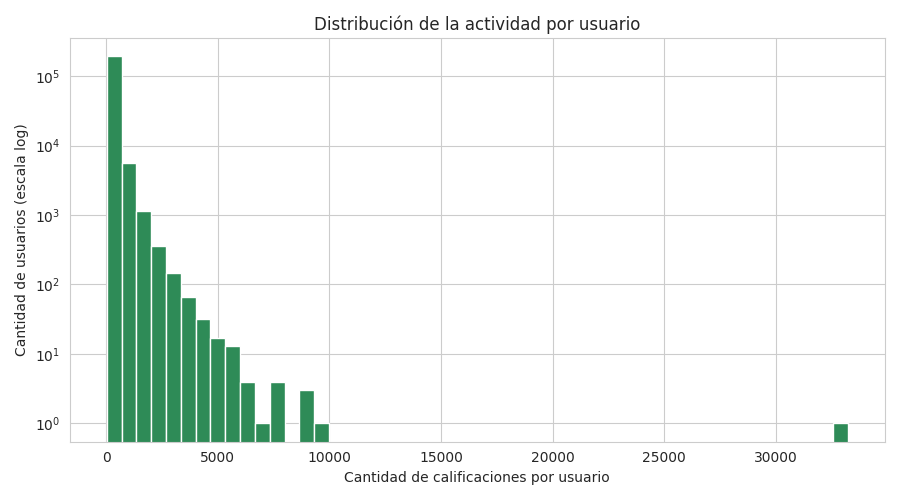

In [14]:
plt.figure(figsize=(9, 5))
ratings_por_usuario.plot(kind='hist', bins=50, color='seagreen', log=True)
plt.xlabel('Cantidad de calificaciones por usuario')
plt.ylabel('Cantidad de usuarios (escala log)')
plt.title('Distribución de la actividad por usuario')
plt.tight_layout()
plt.show()

**Resultados:** en promedio cada usuario califica 159.07 películas, pero la mediana es solo 73 —
la media está muy por encima de la mediana, señal clara de asimetría hacia la derecha. El usuario
mínimo tiene 18 calificaciones (probablemente un umbral impuesto por MovieLens al construir el
dataset) y el más activo (`userId` 175325) tiene 33,229, casi 460 veces más que el usuario mediano.
Con la regla de 1.5×IQR (Q1=36, Q3=166.25, límite superior=361.625), cualquier usuario con más de ~362
calificaciones es técnicamente un valor atípico: son 20,228 usuarios (10.07% del total).

**Conclusión:** la actividad de calificación tiene una **cola larga**, pero mucho menos extrema que la
de `tags`: en `tags`, un solo usuario concentraba el 36.2% de toda la actividad; aquí, el usuario más
activo (33,229 calificaciones) representa apenas el 0.10% del total. Esto sugiere que la actividad de
calificación es más genuinamente distribuida entre muchos usuarios reales, sin un caso tan extremo de
posible automatización como el encontrado en `tags`. Aun así, sigue siendo relevante para análisis
futuros: cualquier estadística "por usuario" es menos confiable para los usuarios con pocas
calificaciones (cerca del mínimo de 18) que para los muy activos, y el 10% de usuarios más activos
podría sesgar promedios generales si no se pondera correctamente.

## 7. Conclusiones y limitaciones

### Conclusiones

1. `ratings.csv` tiene 31,963,989 calificaciones limpias (sin nulos ni duplicados), de 200,948
   usuarios sobre 83,852 películas (96.4% del catálogo) — la tabla con mayor cobertura de las tres del
   proyecto.
2. `rating` se distribuye entre 0.5 y 5.0 con moda en 4.0; la mediana (3.5) es levemente menor que la
   moda, indicando asimetría hacia la izquierda, y hay un sesgo claro hacia valores enteros sobre
   valores intermedios (.5).
3. La actividad de calificación por año muestra oleadas (picos en 1996, 2000, 2005, 2015-2017) más que
   un crecimiento sostenido, probablemente ligadas a eventos de la plataforma más que a actividad
   orgánica constante.
4. La actividad por usuario tiene cola larga (mediana de 73 calificaciones, máximo de 33,229), pero
   mucho menos extrema que la encontrada en `tags`: no hay evidencia de un usuario dominante o
   posiblemente automatizado como el `userId` 78213 de `tags`.

### Limitaciones

* `rating_datetime` refleja cuándo se registró la calificación en la plataforma, no necesariamente
  cuándo se vio la película.
* No se aplicó la regla de outliers por IQR a `rating` en sí, porque es una variable ordinal y acotada
  (0.5-5.0): sus extremos son valores válidos de la escala, no anomalías.
* Este análisis usa únicamente `ratings`; no incorpora el catálogo de películas ni las etiquetas, por
  lo que no permite decir si ciertos géneros o tipos de película se califican distinto — ese cruce
  corresponde a `movies_ratings.ipynb` y `movies_tags_ratings.ipynb`.